# Bitcoin Exploratory Data Analysis

Purpose: understand the processed dataset and surface potential modelling problems
(non-stationarity, fat tails, volatility clustering, weak/no autocorrelation) before any
model is built. This notebook does **not** assume Bitcoin has predictable patterns —
it looks for evidence either way.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf

DATA_PATH = "../data/processed/BTC-USD_1d.csv"

df = pd.read_csv(DATA_PATH, index_col="timestamp", parse_dates=True)
df.shape, df.index.min(), df.index.max()

((1827, 7), Timestamp('2021-08-21 00:00:00'), Timestamp('2026-08-21 00:00:00'))

In [2]:
df.head()

,open,high,low,close,volume,daily_return,log_return
timestamp,,,,,,,
2021-08-21,49327.074219,49717.019531,48312.199219,48905.492188,40585205312,NaN,NaN
2021-08-22,48869.105469,49471.609375,48199.941406,49321.652344,25370975378,0.008509,0.008473
2021-08-23,49291.675781,50482.078125,49074.605469,49546.148438,34305053719,0.004552,0.004541
2021-08-24,49562.347656,49878.769531,47687.117188,47706.117188,35361168834,-0.037138,-0.037845
2021-08-25,47727.257812,49202.878906,47163.613281,48960.789062,32646349931,0.026300,0.025960


## Price trend

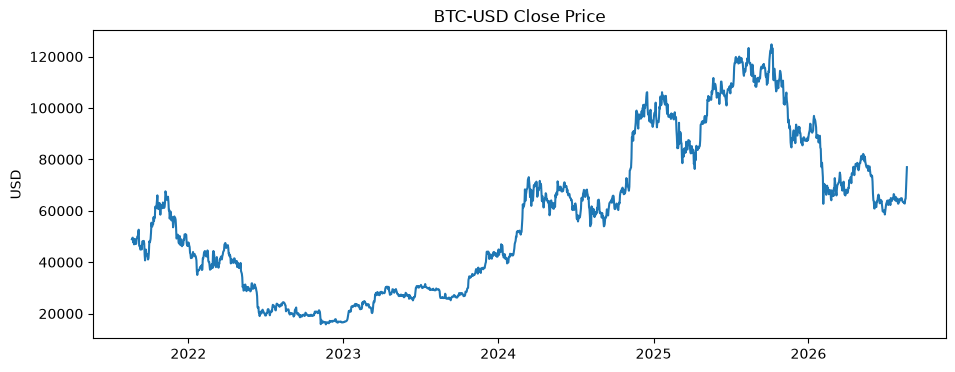

In [3]:
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(df.index, df["close"])
ax.set_title("BTC-USD Close Price")
ax.set_ylabel("USD")
plt.show()

## Daily returns

In [4]:
df["daily_return"].describe()

count    1826.000000
mean        0.000621
std         0.027270
min        -0.159747
25%        -0.012389
50%        -0.000240
75%         0.013184
max         0.145412
Name: daily_return, dtype: float64

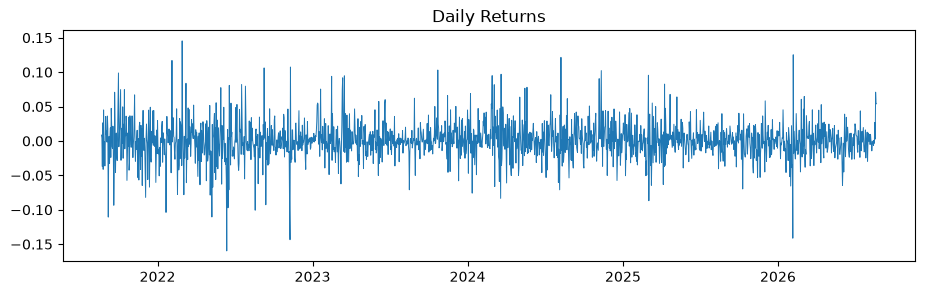

In [5]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(df.index, df["daily_return"], linewidth=0.7)
ax.set_title("Daily Returns")
plt.show()

## Rolling mean and rolling volatility

Rolling statistics use only past and current observations (`.rolling(window)` looks
backward by default), so this is safe for later use as a model feature.

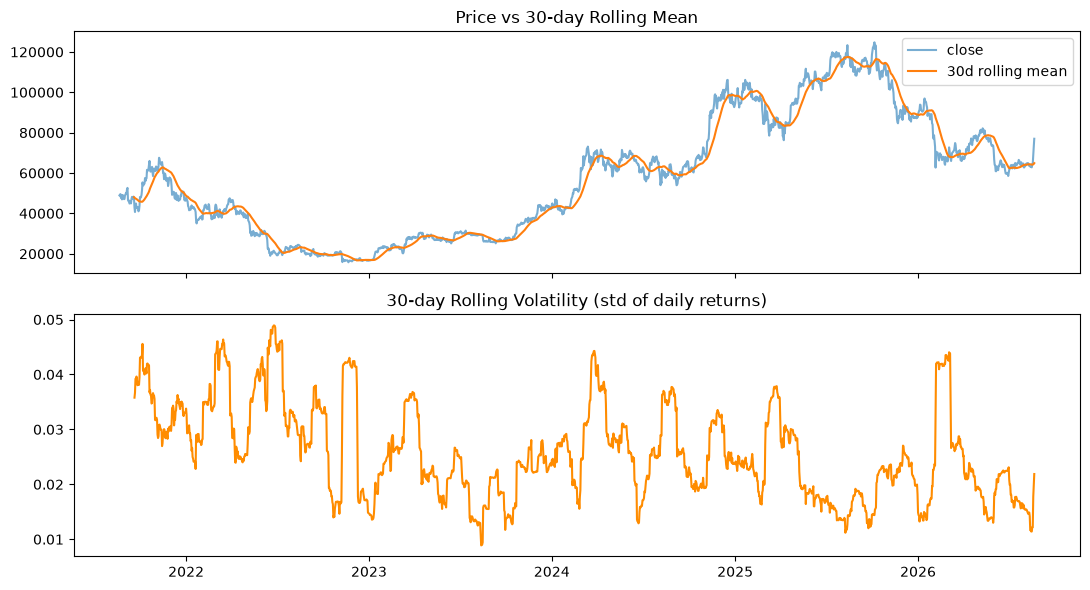

In [6]:
df["rolling_mean_30"] = df["close"].rolling(30).mean()
df["rolling_vol_30"] = df["daily_return"].rolling(30).std()

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(df.index, df["close"], label="close", alpha=0.6)
axes[0].plot(df.index, df["rolling_mean_30"], label="30d rolling mean")
axes[0].legend()
axes[0].set_title("Price vs 30-day Rolling Mean")

axes[1].plot(df.index, df["rolling_vol_30"], color="darkorange")
axes[1].set_title("30-day Rolling Volatility (std of daily returns)")
plt.tight_layout()
plt.show()

## Trading volume

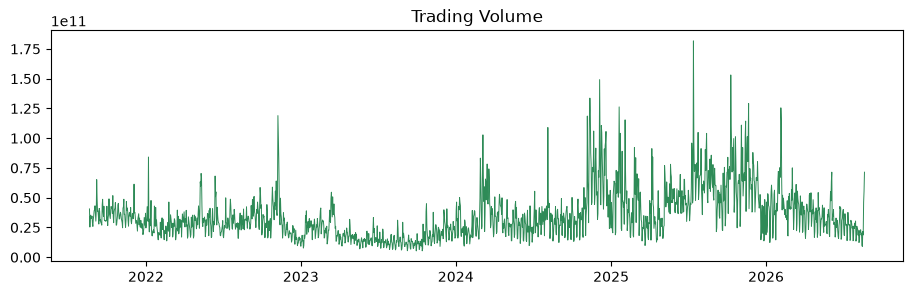

In [7]:
fig, ax = plt.subplots(figsize=(11, 3))
ax.plot(df.index, df["volume"], linewidth=0.7, color="seagreen")
ax.set_title("Trading Volume")
plt.show()

## Drawdowns

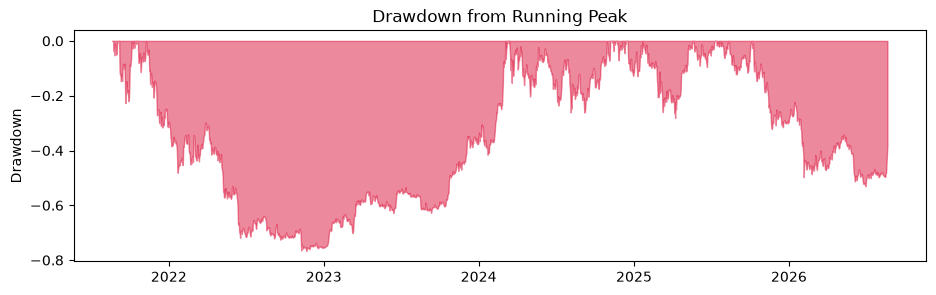

Max drawdown over period: -0.7663456370856909


In [8]:
running_max = df["close"].cummax()
drawdown = df["close"] / running_max - 1

fig, ax = plt.subplots(figsize=(11, 3))
ax.fill_between(df.index, drawdown, 0, color="crimson", alpha=0.5)
ax.set_title("Drawdown from Running Peak")
ax.set_ylabel("Drawdown")
plt.show()

print("Max drawdown over period:", drawdown.min())

## Distribution of returns

Compare against a normal distribution — financial returns are typically fat-tailed,
which matters for how prediction intervals should later be constructed.

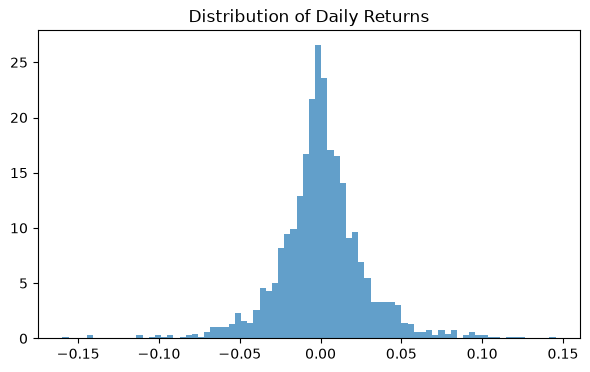

Skew: 0.03836757943175203
Excess kurtosis: 4.013458546640514


In [9]:
returns = df["daily_return"].dropna()

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(returns, bins=80, density=True, alpha=0.7)
ax.set_title("Distribution of Daily Returns")
plt.show()

print("Skew:", returns.skew())
print("Excess kurtosis:", returns.kurtosis())

## Autocorrelation

Checks whether past returns have any linear relationship with future returns. Little to
no significant autocorrelation would be consistent with near-random-walk behaviour, which
is common for liquid asset prices — this does not itself justify or rule out modelling,
but it sets expectations for how much a linear model can realistically capture.

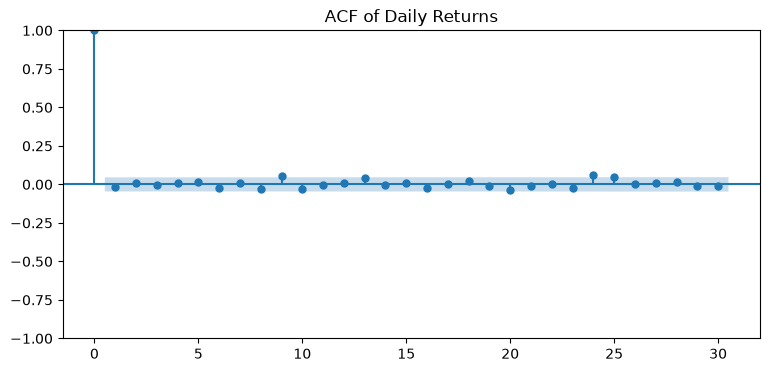

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_acf(returns, lags=30, ax=ax)
ax.set_title("ACF of Daily Returns")
plt.show()

## Seasonal patterns (day of week)

Purely descriptive — with ~5 years of daily data, any day-of-week effect found here is
likely to be noise rather than a reliable pattern, and should not be treated as a
trading signal without further statistical testing.

In [11]:
by_dow = df.assign(dow=df.index.day_name())["daily_return"].groupby(df.index.day_name()).mean()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
by_dow = by_dow.reindex(order)
by_dow

timestamp
Monday       0.002663
Tuesday     -0.000620
Wednesday    0.003488
Thursday    -0.003072
Friday       0.000217
Saturday     0.000127
Sunday       0.001539
Name: daily_return, dtype: float64

## Summary

- Price shows strong non-stationary trend behaviour — raw close price is not directly
  suitable as a stationary model input; returns are the more natural target (Stage 5).
- Volatility clusters over time (visible in the rolling-volatility plot), so a single
  fixed error band is unlikely to represent uncertainty well across the whole period.
- Return distribution is fat-tailed relative to normal, which should inform how
  prediction intervals are built later (Stage 11) rather than assuming normality.
- No strong, obviously exploitable autocorrelation or day-of-week effect is evident from
  this plot alone — consistent with the plan's instruction not to assume Bitcoin has
  predictable patterns. This motivates starting from naive/moving-average baselines
  (Stage 6) before trusting any more complex model's apparent skill.